In [6]:
import json
import random
from collections import defaultdict
from src.grammar.basic_generator import BasicGrammar
from src.grammar.controlled_generator import ControlledFSM
from src.grammar.examples import GRAMMARS, ALL_LOWERCASE_LETTERS

In [26]:
fsms = {}
for i in range(3, 15):
    num_tries = random.randint(0,3)
    for num_try in range(num_tries):
        init_params = {"num_states": i, "alphabet": random.sample(ALL_LOWERCASE_LETTERS, random.randint(2, 10))}
        fsmname = f"s{i}_a{len(init_params['alphabet'])}_try{num_try}"
        fsms[fsmname] = ControlledFSM(**init_params)
        fsms[fsmname].build(
            max_out=random.randint(1, init_params["num_states"]//2),
            num_backward_edges=random.randint(0,max(1,init_params["num_states"]//4)),
            num_loops=random.randint(1,max(1,init_params["num_states"]//4)),
            loop_length_range=(1,random.randint(2,init_params["num_states"]-1)),
            num_accept=random.randint(1, max(1,init_params["num_states"]//2))
        )

Added 1 forward edges in backbone DAG
Added 0 backward edges in DAG
Added 1 loops in DAG
Number of accept states: 1
The graph is validated!
Added 1 forward edges in backbone DAG
Added 0 backward edges in DAG
Added 1 loops in DAG
Number of accept states: 1
The graph is validated!
Added 1 forward edges in backbone DAG
Added 0 backward edges in DAG
Added 1 loops in DAG
Number of accept states: 1
The graph is validated!
Added 0 forward edges in backbone DAG
Added 0 backward edges in DAG
Added 1 loops in DAG
Number of accept states: 2
The graph is validated!
Added 1 forward edges in backbone DAG
Added 0 backward edges in DAG
Added 1 loops in DAG
Number of accept states: 1
The graph is validated!
Added 4 forward edges in backbone DAG
Added 1 backward edges in DAG
Added 1 loops in DAG
Number of accept states: 1
The graph is validated!
Added 5 forward edges in backbone DAG
Added 1 backward edges in DAG
Added 1 loops in DAG
Number of accept states: 1
The graph is validated!
Added 5 forward edge

AssertionError: Unreachable states exist

In [27]:
fsms.keys()


dict_keys(['s3_a6_try0', 's3_a8_try1', 's3_a4_try2', 's4_a10_try0', 's4_a10_try1', 's7_a3_try0', 's7_a4_try1', 's7_a8_try2', 's8_a7_try0', 's9_a9_try0', 's10_a5_try0'])

In [56]:
path = f"generated_grammars/s7_a7.json"
ex_fsm.to_json(path)

In [57]:
loadedexfsm = BasicGrammar.from_json(path)

In [58]:
loadedexfsm.transitions


{0: {'o': 1, 'p': 2, 't': 2},
 1: {'d': 3, 'f': 6, 'w': 1},
 2: {'f': 5},
 3: {'d': 4, 'z': 5, 'p': 4, 'w': 6},
 4: {'z': 5},
 5: {'p': 2},
 6: {'f': 4}}

In [59]:

ex_fsm.transitions

{0: {'o': 1, 'p': 2, 't': 2},
 1: {'d': 3, 'f': 6, 'w': 1},
 2: {'f': 5},
 3: {'d': 4, 'z': 5, 'p': 4, 'w': 6},
 4: {'z': 5},
 5: {'p': 2},
 6: {'f': 4}}

In [55]:
len(ex_fsm._compute_effective_alphabet())

7

{0, 2, 4}
Accept states: {0, 2, 4}


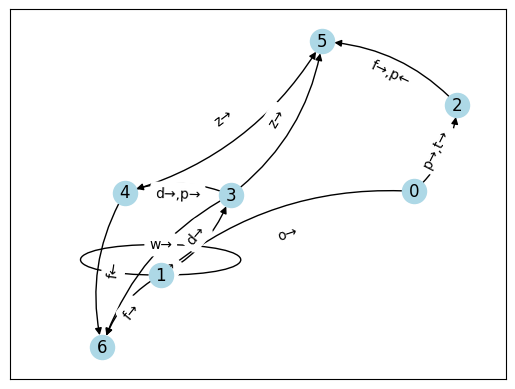

In [52]:
ex_fsm = fsms["s7_a8_try2"]
print(ex_fsm.accept_states)
ex_fsm.visualize()


In [2]:
fsms = {}
for gname, gjson in GRAMMARS.items():
    fsms[gname] = BasicGrammar.from_json(
        gjson, #.replace("\n", ""),
        is_path=False
    )
    print(gname, "loaded")

SIMPLE_LOOP_GRAMMAR loaded
ALTERNATING_AB_LOOP_GRAMMAR loaded
ALTERNATING_ABEXPONENT_LOOP_GRAMMAR loaded
ALTERNATING_CONSONANT_VOWEL_LOOP_GRAMMAR loaded
ALTERNATING_CONSONANT_VOWELEXPONENT_LOOP_GRAMMAR loaded
ALTERNATING_GIBBEGIBBERISH_LOOP_GRAMMAR loaded
ALTERNATING_GIBBEGIBBERISHEXPONENT_LOOP_GRAMMAR loaded
LADDER_GRAMMAR loaded
WAYBACK_GRAMMAR loaded
ALTERNATING_MUSTSTOP_LOOP_GRAMMAR loaded
ALTERNATING_MUSTSTOPEXPONENT_LOOP_GRAMMAR loaded
WAYBACK_WORD_GRAMMAR loaded


In [17]:
UPPER_LIMIT_VALID_SAMPLE_GENERATION = 1000
MAX_CHARS = 75
first_valid_samples = {}
for fsmname in fsms.keys():
    first_valid_samples[fsmname] = fsms[fsmname].enumerate_valid_samples(
            max_len=MAX_CHARS,
            early_stop_function=lambda x: len(x) > UPPER_LIMIT_VALID_SAMPLE_GENERATION
        )

In [18]:
MAX_NUMBER_INVALID = 300
first_invalid_samples = defaultdict(set)
for fsmname in fsms.keys():
    original_alphabet = fsms[fsmname].alphabet
    if len(original_alphabet) < 3:
        fsms[fsmname].alphabet = list(set(fsms[fsmname].alphabet).union({"a","b","c"}))
    while len(first_invalid_samples[fsmname]) < MAX_NUMBER_INVALID:
        first_invalid_samples[fsmname].add(fsms[fsmname].generate_invalid(max_len=MAX_CHARS))
    first_invalid_samples[fsmname] = sorted(first_invalid_samples[fsmname], key=lambda x: len(x))
    fsms[fsmname].alphabet = original_alphabet

In [22]:
len(first_valid_samples["ALTERNATING_ABEXPONENT_LOOP_GRAMMAR"])

1002